In [18]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from blinksear import isBlinkByEar
from blinksear import isBlinkByEar1
from blinksear import isBlinkByEar2
from blinksdistance import BlinkDistance
from blinkscolors import Colors
from blinkscorrelation import Correlation


In [ ]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [41]:
files = Path("./thresholds").glob("*.csv")
metodo = "DIST"
for file in files:
    if metodo in str(file):
        df = pd.read_csv(file)

threshold_columns = [col for col in df.columns if col not in ['trial', 'Should be']]

# Eliminar filas no numéricas en la columna 'trial' (como 'total')
df_clean = df[pd.to_numeric(df['trial'], errors='coerce').notnull()].copy()
df_clean['trial'] = df_clean['trial'].astype(int)

# Repetir el cálculo con el DataFrame limpio

# Resultados globales
results_global = []
for threshold in threshold_columns:
    preds = df_clean[threshold]
    truth = df_clean['Should be']
    mae = np.mean(np.abs(preds - truth))
    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    results_global.append({'Threshold': threshold, 'Error Absoluto Medio': mae, 'Error Cuadrático Medio': rmse})

results_global_df = pd.DataFrame(results_global).sort_values(by='Error Absoluto Medio')

# Resultados por trial
results_by_trial = {}
for _, row in df_clean.iterrows():
    trial_id = int(row['trial'])
    truth = row['Should be']
    trial_results = []
    for threshold in threshold_columns:
        pred = row[threshold]
        mae = abs(pred - truth)
        rmse = np.sqrt((pred - truth) ** 2)
        trial_results.append({'Threshold': threshold, 'Error Absoluto Medio': mae, 'Error Cuadrático Medio': rmse})
    results_by_trial[trial_id] = pd.DataFrame(trial_results).sort_values(by='Error Absoluto Medio')

results_global_df.head()  # Mostrar mejores thresholds globales según MAE
##results_by_trial[6]



,Threshold,Error Absoluto Medio,Error Cuadrático Medio
6,0.45,11.500000,17.592612
10,0.44,11.500000,17.902514
11,0.46,12.333333,17.156146
7,0.5,12.833333,14.312000
14,0.51,13.166667,16.436747


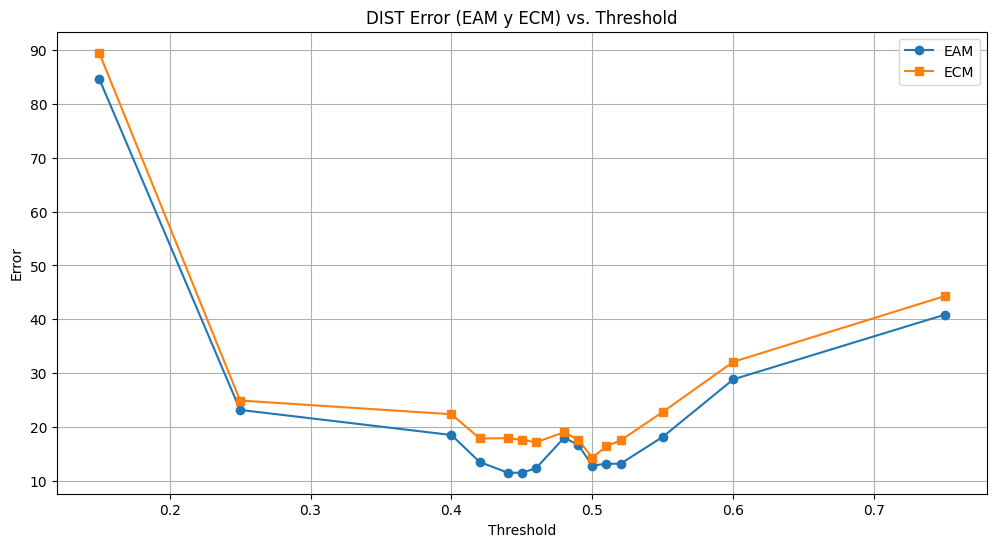

In [42]:
# Calcular MAE y RMSE por threshold
results = []
for threshold in threshold_columns:
    preds = df_clean[threshold]
    truth = df_clean['Should be']
    mae = np.mean(np.abs(preds - truth))
    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    results.append({
        'Threshold': threshold,
        'Threshold_float': float(str(threshold).replace(",", ".").replace(" ", "")),
        'MAE': mae,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results).sort_values('Threshold_float')

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(results_df['Threshold_float'], results_df['MAE'], label='EAM', marker='o')
plt.plot(results_df['Threshold_float'], results_df['RMSE'], label='ECM', marker='s')
plt.xlabel("Threshold")
plt.ylabel("Error")
plt.title(metodo + " Error (EAM y ECM) vs. Threshold")
plt.legend()
plt.grid(True)
plt.show()


In [30]:
results_df

,Threshold,Threshold_float,MAE,RMSE
0,0.15,0.150,86.666667,91.651514
1,0.2,0.200,70.833333,77.029215
2,0.22,0.220,47.166667,53.979935
3,0.23,0.230,39.000000,44.650495
4,0.25,0.250,17.833333,19.265686
7,0.265,0.265,17.500000,19.574643
5,0.27,0.270,18.500000,20.070708
8,0.285,0.285,16.833333,21.775368
10,0.29,0.290,15.500000,19.213710
6,0.3,0.300,13.833333,19.895561
